In [4]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import random
import os
from typing import TypedDict
from langgraph.prebuilt import ToolNode, tools_condition




c:\Users\Soufiane1\Desktop\projects\ai\agentic\langGraph_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
load_dotenv(override=True)


True

In [6]:
from langchain_community.utilities import GoogleSerperAPIWrapper

serper = GoogleSerperAPIWrapper()
#serper.run("What is the capital of France?")

In [7]:
from langchain_core.tools import Tool
search_tool = Tool(
      name="search",
      func=serper.run,
      description="Invoked when an online search is needed"
)
#search_tool.invoke("What is the capital of France?")

In [8]:
##custom tool
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = os.getenv("PUSHOVER_URL")

import requests

def push(text: str):
      """Makes a push notification to user"""
      requests.post(pushover_url , data = {"token":pushover_token, "user":pushover_user, "message":text})


In [9]:
push_tool = Tool(
      name="push_notification",
      func=push,
      description="Invoked when we need to send a notification to user"
)
#push_tool.invoke("Hey ffrom tool in langchain")

New Project of langchain with tools

In [10]:
class State(TypedDict):
      messages: Annotated[list, add_messages]

In [11]:
graph_builder = StateGraph(State)

In [32]:
llm = ChatOpenAI(model="gpt-4o-mini")
tools=[push_tool, search_tool]
llm_with_tools = llm.bind_tools(tools)

In [35]:
#creat node: input llm output
def chatbot(state: State):
    response = llm_with_tools.invoke(state["messages"])
    new_state = {"messages": [response]} #AImesssage object
    return new_state
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

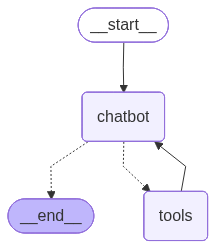

In [36]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
def chat(user_input: str, history):
    response = graph.invoke({
        "messages": history + [{"role": "user", "content": user_input}]
    })
    
    return response["messages"][-1].content
gr.ChatInterface(chat).launch()

In [8]:
## in memeory store
from langgraph.checkpoint.memory import MemorySaver
memeory = MemorySaver()

In [11]:
graph_builder = StateGraph(State)

In [12]:
llm = ChatOpenAI(model="gpt-4o-mini")
tools=[push_tool, search_tool]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    response = llm_with_tools.invoke(state["messages"])
    new_state = {"messages": [response]} #AImesssage object
    return new_state

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

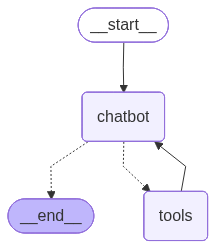

In [15]:
graph = graph_builder.compile(checkpointer=memeory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
config = {"configurable": {"thread_id": "1"}}
def chat(user_input: str, history):
      print(user_input)
      response = graph.invoke({"messages":[{"role":"user", "content":user_input}]}, config=config)
      print(response)
      return response["messages"][-1].content
gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


hi
{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='8cf00138-03d0-4dfa-93ed-0175721a33d4'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 86, 'total_tokens': 96, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_888e567758', 'id': 'chatcmpl-DV79aZCdeDSq7bdiBx633HhTB0AKb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d9435-a370-7ec1-a18a-57fb08e34cdf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 86, 'output_tokens': 10, 'total_tokens': 96, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_detail

In [21]:
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='8cf00138-03d0-4dfa-93ed-0175721a33d4'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 86, 'total_tokens': 96, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_888e567758', 'id': 'chatcmpl-DV79aZCdeDSq7bdiBx633HhTB0AKb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d9435-a370-7ec1-a18a-57fb08e34cdf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 86, 'output_tokens': 10, 'total_tokens': 96, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o

In [23]:
list(graph.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='8cf00138-03d0-4dfa-93ed-0175721a33d4'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 86, 'total_tokens': 96, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_888e567758', 'id': 'chatcmpl-DV79aZCdeDSq7bdiBx633HhTB0AKb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d9435-a370-7ec1-a18a-57fb08e34cdf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 86, 'output_tokens': 10, 'total_tokens': 96, 'input_token_details': {'audio': 0, 'cache_read': 0}, '

In [12]:
##sql lite
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

db_path="memory.db"
conn = sqlite3.connect(db_path, check_same_thread=False)
sqlmemory = SqliteSaver(conn)


In [16]:
graph_builder = StateGraph(State)
llm = ChatOpenAI(model="gpt-4o-mini")
tools=[push_tool, search_tool]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    response = llm_with_tools.invoke(state["messages"])
    new_state = {"messages": [response]} #AImesssage object
    return new_state

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

graph = graph_builder.compile(checkpointer=sqlmemory)
config = {"configurable": {"thread_id": "3"}}
def chat(user_input: str, history):
      print(user_input)
      response = graph.invoke({"messages":[{"role":"user", "content":user_input}]}, config=config)
      print(response)
      return response["messages"][-1].content
gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


what my name
{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='bd8276ff-a9b5-40da-9fdd-53afb90476aa'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 86, 'total_tokens': 96, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_888e567758', 'id': 'chatcmpl-DVC5DlqSWDOMC206ZSiVG96kNGgrE', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d9556-c56b-7d92-b233-91379177831d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 86, 'output_tokens': 10, 'total_tokens': 96, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_to